# Data set Build 

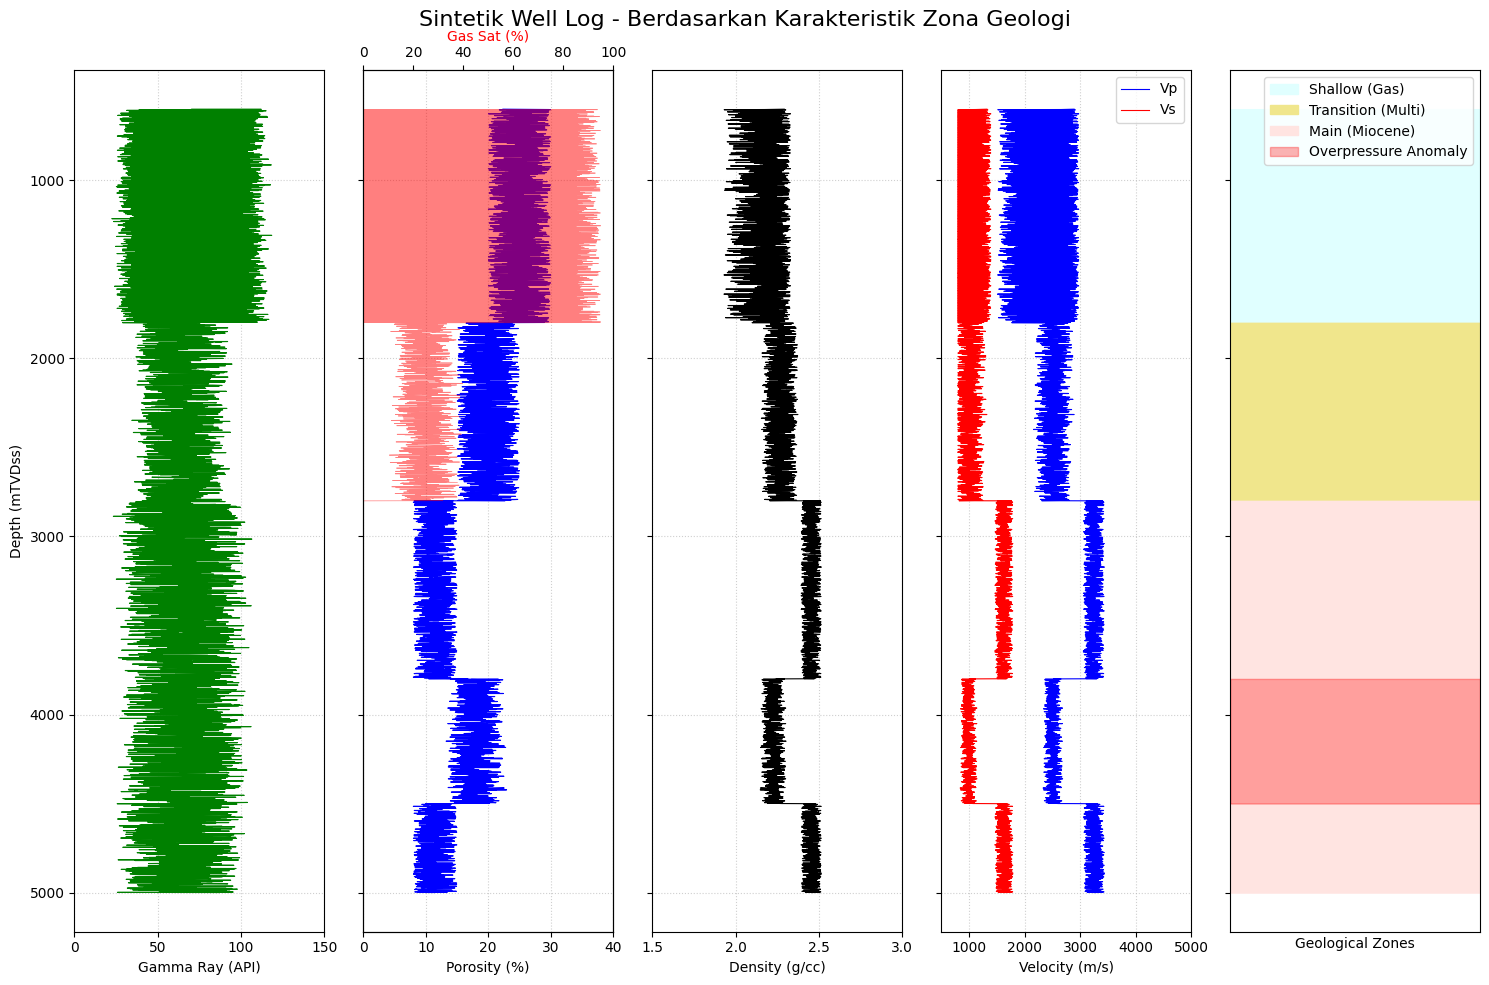

Data set berhasil disimpan ke dalam file: synthetic_well_log_dataset.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP PARAMETER DASAR & KEDALAMAN
# ==========================================
# Resolusi log 1 meter, dari 600 hingga 5000 mTVDss
depth = np.arange(600, 5001, 1)
n = len(depth)

# Parameter Matriks (Batu Pasir/Sandstone)
rho_ma = 2.65     # g/cc
vp_ma = 3950      # m/s

# Parameter Fluida
rho_w, vp_w = 1.05, 1500  # Brine water
rho_o, vp_o = 0.80, 1200  # Light oil
rho_g, vp_g = 0.20, 600   # Biogenic Gas (C1)

# Inisialisasi array
phi = np.zeros(n)
vsh = np.zeros(n)
sw, so, sg = np.zeros(n), np.zeros(n), np.zeros(n)
overpressure_flag = np.zeros(n)

# ==========================================
# 2. PEMODELAN ZONA GEOLOGI
# ==========================================
# A. ZONA DANGKAL (600 - 1800 m) - Sedimen Pliosen
idx_shallow = (depth >= 600) & (depth < 1800)
phi[idx_shallow] = np.random.uniform(0.20, 0.30, sum(idx_shallow))
vsh[idx_shallow] = 0.5 + 0.4 * np.sin(2 * np.pi * depth[idx_shallow] / 4.0) 
vsh[idx_shallow] = np.clip(vsh[idx_shallow] + np.random.normal(0, 0.05, sum(idx_shallow)), 0.1, 0.9)

# Jika Vsh rendah (Sand), dominan gas metana (>90% C1)
is_sand = vsh[idx_shallow] < 0.4
sg_temp = np.zeros(sum(idx_shallow))
sg_temp[is_sand] = np.random.uniform(0.85, 0.95, sum(is_sand)) # >90% C1
sg[idx_shallow] = sg_temp
sw[idx_shallow] = 1 - sg[idx_shallow]

# B. ZONA TRANSISI (1800 - 2800 m) - Intrabeta & SU1
idx_trans = (depth >= 1800) & (depth < 2800)
phi[idx_trans] = np.random.uniform(0.15, 0.25, sum(idx_trans))
vsh[idx_trans] = np.random.uniform(0.2, 0.7, sum(idx_trans))
sw[idx_trans] = np.random.uniform(0.3, 0.5, sum(idx_trans))
so[idx_trans] = np.random.uniform(0.3, 0.4, sum(idx_trans))
sg[idx_trans] = 1 - (sw[idx_trans] + so[idx_trans])

# C. ZONA UTAMA (2800 - 5000 m) - Seri Batuan Miosen
idx_main = (depth >= 2800) & (depth <= 5000)
phi[idx_main] = np.random.uniform(0.08, 0.15, sum(idx_main))
vsh[idx_main] = np.random.uniform(0.1, 0.8, sum(idx_main))
sw[idx_main] = np.random.uniform(0.5, 0.7, sum(idx_main))
so[idx_main] = 1 - sw[idx_main]

# Simulasi Overpressure
idx_op = (depth >= 3800) & (depth <= 4500)
overpressure_flag[idx_op] = 1
phi[idx_op] = phi[idx_op] + np.random.uniform(0.05, 0.08, sum(idx_op))

# ==========================================
# 3. PERHITUNGAN PERSAMAAN GEOFISIKA
# ==========================================
# Gamma Ray
gr = 20 + vsh * (120 - 20) + np.random.normal(0, 3, n)

# Densitas Bulk
rho_fl = (sw * rho_w) + (sg * rho_g) + (so * rho_o)
rhob = (phi * rho_fl) + ((1 - phi) * rho_ma)

# Kecepatan Vp (Wyllie Time Average)
dt_fl = (sw / vp_w) + (sg / vp_g) + (so / vp_o) 
dt_fl = np.where(dt_fl == 0, 1/vp_w, dt_fl) 
dt_log = (phi * dt_fl) + ((1 - phi) * (1 / vp_ma))
vp = 1 / dt_log

# Koreksi drop Vp akibat overpressure di Zona Utama
vp = np.where(overpressure_flag == 1, vp * 0.85, vp)
rhob = np.where(overpressure_flag == 1, rhob * 0.95, rhob)

# Kecepatan Vs (Castagna)
vs = (0.862 * vp) - 1172
vs = np.clip(vs, 800, None)

# Impedansi Akustik (AI)
ai = vp * rhob

# Buat DataFrame
df_well = pd.DataFrame({
    'Depth_m': depth, 'GR': gr, 'Vsh': vsh, 'Phi': phi,
    'Sw': sw, 'So': so, 'Sg': sg, 'RHOB': rhob, 
    'Vp': vp, 'Vs': vs, 'AI': ai, 'Zone': ''
})

df_well.loc[idx_shallow, 'Zone'] = 'Zona Dangkal (TSZ)'
df_well.loc[idx_trans, 'Zone'] = 'Zona Transisi'
df_well.loc[idx_main, 'Zone'] = 'Zona Utama (TMZ)'

# ==========================================
# 4. VISUALISASI DATA LOG (LOG PLOT)
# ==========================================
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(15, 10), sharey=True)
fig.suptitle('Sintetik Well Log - Berdasarkan Karakteristik Zona Geologi', fontsize=16)

# Track 1: Gamma Ray
ax[0].plot(df_well['GR'], df_well['Depth_m'], color='green', linewidth=0.8)
ax[0].set_xlabel('Gamma Ray (API)')
ax[0].set_xlim(0, 150)
ax[0].grid(True, linestyle=':', alpha=0.6)

# Track 2: Porosity & Fluid Saturation
ax[1].plot(df_well['Phi']*100, df_well['Depth_m'], color='blue', label='Porosity (%)', linewidth=0.8)
ax[1].set_xlabel('Porosity (%)')
ax[1].set_xlim(0, 40)
ax[1].grid(True, linestyle=':', alpha=0.6)
ax1_twin = ax[1].twiny()
ax1_twin.plot(df_well['Sg']*100, df_well['Depth_m'], color='red', alpha=0.5, label='Sg (%)', linewidth=0.5)
ax1_twin.set_xlim(0, 100)
ax1_twin.set_xlabel('Gas Sat (%)', color='red')

# Track 3: Density
ax[2].plot(df_well['RHOB'], df_well['Depth_m'], color='black', linewidth=0.8)
ax[2].set_xlabel('Density (g/cc)')
ax[2].set_xlim(1.5, 3.0)
ax[2].grid(True, linestyle=':', alpha=0.6)

# Track 4: Vp & Vs
ax[3].plot(df_well['Vp'], df_well['Depth_m'], color='blue', label='Vp', linewidth=0.8)
ax[3].plot(df_well['Vs'], df_well['Depth_m'], color='red', label='Vs', linewidth=0.8)
ax[3].set_xlabel('Velocity (m/s)')
ax[3].set_xlim(500, 5000)
ax[3].legend(loc='upper right')
ax[3].grid(True, linestyle=':', alpha=0.6)

# Track 5: Zones & Overpressure
ax[4].fill_betweenx(df_well['Depth_m'], 0, 1, where=idx_shallow, color='lightcyan', label='Shallow (Gas)')
ax[4].fill_betweenx(df_well['Depth_m'], 0, 1, where=idx_trans, color='khaki', label='Transition (Multi)')
ax[4].fill_betweenx(df_well['Depth_m'], 0, 1, where=idx_main, color='mistyrose', label='Main (Miocene)')
ax[4].fill_betweenx(df_well['Depth_m'], 0, 1, where=idx_op, color='red', alpha=0.3, label='Overpressure Anomaly')
ax[4].set_xlabel('Geological Zones')
ax[4].set_xlim(0, 1)
ax[4].set_xticks([])
ax[4].legend(loc='upper right')

ax[0].invert_yaxis()
ax[0].set_ylabel('Depth (mTVDss)')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

# ==========================================
# 5. EXPORT KE FORMAT CSV
# ==========================================
csv_filename = 'synthetic_well_log_dataset.csv'
df_well.to_csv(csv_filename, index=False)
print(f"Data set berhasil disimpan ke dalam file: {csv_filename}")

# AVO analysis

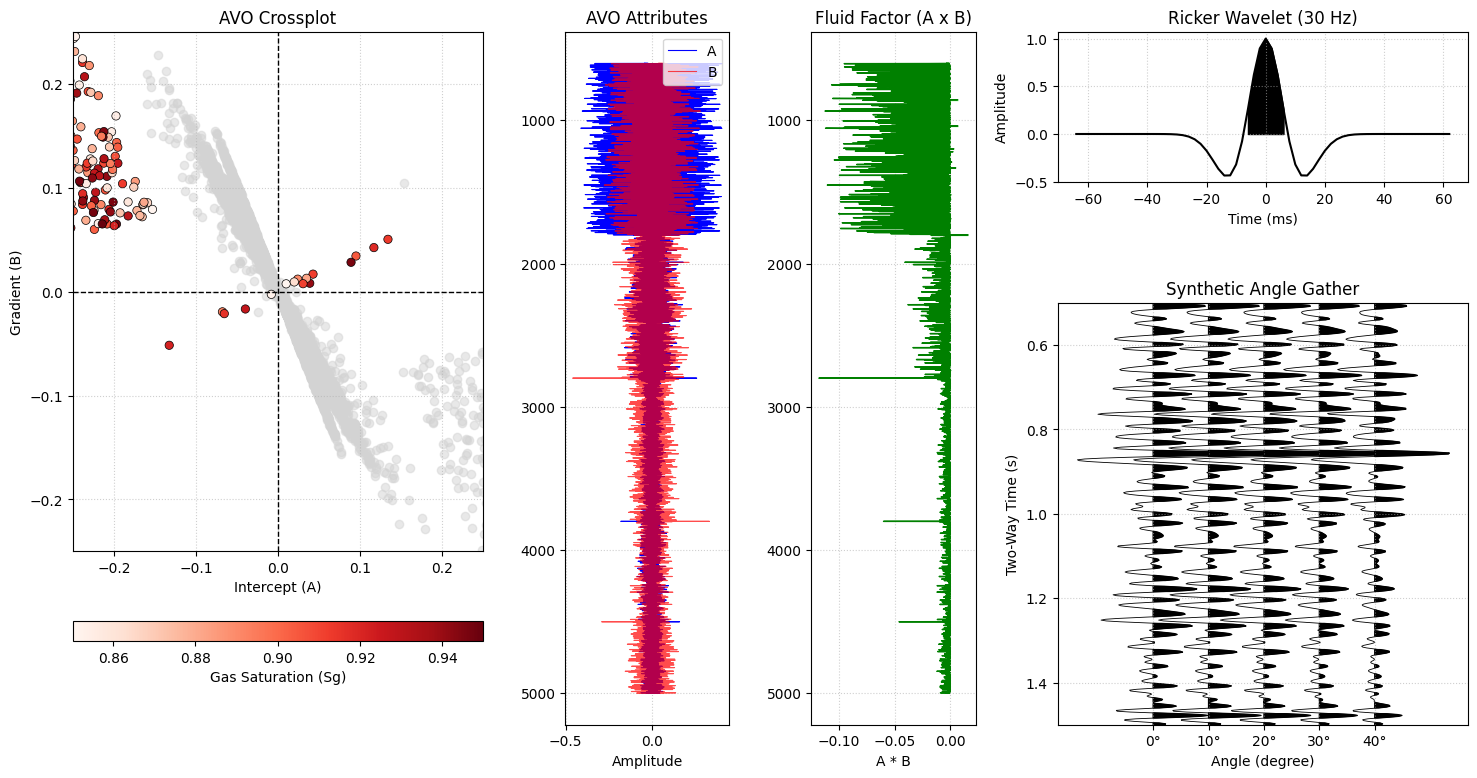

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. MEMBACA DATASET & TIME-DEPTH CONVERSION
# ==========================================
df = pd.read_csv('synthetic_well_log_dataset.csv')

# Menghitung Two-Way Travel Time (TWT) untuk plotting seismik
# Asumsi dz = 1 meter dari resolusi log sebelumnya
df['dt_s'] = 1.0 / df['Vp'] # Waktu tempuh satu arah (detik) per meter
df['TWT'] = 2 * df['dt_s'].cumsum() # Waktu tempuh dua arah kumulatif ke dasar log

# ==========================================
# 2. PERHITUNGAN KONTRAS ANTAR LAPISAN
# ==========================================
vp1, vp2 = df['Vp'].shift(1), df['Vp']
d_vp = vp2 - vp1
avg_vp = (vp1 + vp2) / 2

vs1, vs2 = df['Vs'].shift(1), df['Vs']
d_vs = vs2 - vs1
avg_vs = (vs1 + vs2) / 2

rho1, rho2 = df['RHOB'].shift(1), df['RHOB']
d_rho = rho2 - rho1
avg_rho = (rho1 + rho2) / 2

# ==========================================
# 3. APROKSIMASI SHUEY (2-TERM) & FLUID FACTOR
# ==========================================
A = 0.5 * ((d_vp / avg_vp) + (d_rho / avg_rho))
B = 0.5 * (d_vp / avg_vp) - 2 * (avg_vs / avg_vp)**2 * (2 * (d_vs / avg_vs) + (d_rho / avg_rho))

df['Intercept_A'] = A
df['Gradient_B'] = B
df_avo = df.dropna().copy()
df_avo['A_times_B'] = df_avo['Intercept_A'] * df_avo['Gradient_B']

# ==========================================
# 4. PEMBUATAN RICKER WAVELET
# ==========================================
def ricker_wavelet(f_dom, dt=0.002, length=0.128):
    t = np.arange(-length/2, (length)/2, dt)
    y = (1.0 - 2.0*(np.pi**2)*(f_dom**2)*(t**2)) * np.exp(-(np.pi**2)*(f_dom**2)*(t**2))
    return t, y

dt_resample = 0.002 # Resolusi seismik standar (2 ms)
f_dom = 30 # Frekuensi dominan 30 Hz
t_wavelet, wavelet = ricker_wavelet(f_dom, dt=dt_resample)

# ==========================================
# 5. SYNTHETIC ANGLE GATHER
# ==========================================
# Resample log AVO ke domain waktu (TWT) yang seragam (2 ms interval)
twt_min = np.ceil(df_avo['TWT'].min() / dt_resample) * dt_resample
twt_max = np.floor(df_avo['TWT'].max() / dt_resample) * dt_resample
t_resampled = np.arange(twt_min, twt_max, dt_resample)

A_t = np.interp(t_resampled, df_avo['TWT'], df_avo['Intercept_A'])
B_t = np.interp(t_resampled, df_avo['TWT'], df_avo['Gradient_B'])

# Menentukan sudut datang gelombang
angles = np.arange(0, 50, 10) # 0, 10, 20, 30, 40 derajat
gather = np.zeros((len(t_resampled), len(angles)))

# Membuat Gather per sudut (Shuey equation -> Reflectivity -> Convolution)
for i, theta in enumerate(angles):
    theta_rad = np.radians(theta)
    # R(theta) = A + B * sin^2(theta)
    R_theta = A_t + B_t * np.sin(theta_rad)**2
    # Konvolusi reflektivitas dengan Ricker Wavelet
    trace = np.convolve(R_theta, wavelet, mode='same')
    gather[:, i] = trace

# ==========================================
# 6. VISUALISASI MENGGUNAKAN GRIDSPEC
# ==========================================
fig = plt.figure(figsize=(18, 9))
# Membagi tata letak menjadi 3 Baris dan 6 Kolom
gs = gridspec.GridSpec(3, 6, wspace=0.5, hspace=0.8)

# [Subplot 1] Crossplot A vs B (Kolom 0 sampai 1)
ax1 = fig.add_subplot(gs[:, 0:2])
gas_sands = df_avo[df_avo['Sg'] > 0.5]
background = df_avo[df_avo['Sg'] <= 0.5]
ax1.scatter(background['Intercept_A'], background['Gradient_B'], c='lightgrey', alpha=0.5, label='Background')
sc = ax1.scatter(gas_sands['Intercept_A'], gas_sands['Gradient_B'], c=gas_sands['Sg'], cmap='Reds', edgecolors='k', linewidth=0.5, label='Gas Sand (>50%)')
ax1.axhline(0, color='black', lw=1, linestyle='--')
ax1.axvline(0, color='black', lw=1, linestyle='--')
ax1.set_xlabel('Intercept (A)')
ax1.set_ylabel('Gradient (B)')
ax1.set_title('AVO Crossplot')
ax1.set_xlim(-0.25, 0.25)
ax1.set_ylim(-0.25, 0.25)
ax1.grid(True, linestyle=':', alpha=0.6)
plt.colorbar(sc, ax=ax1, label='Gas Saturation (Sg)', orientation='horizontal', pad=0.1)

# [Subplot 2] Log Atribut AVO (Kolom 2)
ax2 = fig.add_subplot(gs[:, 2])
ax2.plot(df_avo['Intercept_A'], df_avo['Depth_m'], color='blue', linewidth=0.8, label='A')
ax2.plot(df_avo['Gradient_B'], df_avo['Depth_m'], color='red', linewidth=0.8, alpha=0.7, label='B')
ax2.invert_yaxis()
ax2.set_xlabel('Amplitude')
ax2.set_title('AVO Attributes')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle=':', alpha=0.6)

# [Subplot 3] Fluid Factor (Kolom 3)
ax3 = fig.add_subplot(gs[:, 3], sharey=ax2)
ax3.plot(df_avo['A_times_B'], df_avo['Depth_m'], color='green', linewidth=1)
ax3.fill_betweenx(df_avo['Depth_m'], 0, df_avo['A_times_B'], where=(df_avo['A_times_B'] > 0.005), color='lime', alpha=0.5)
ax3.set_xlabel('A * B')
ax3.set_title('Fluid Factor (A x B)')
ax3.grid(True, linestyle=':', alpha=0.6)

# [Subplot 4] Ricker Wavelet (Baris 0, Kolom 4 sampai 5)
ax4 = fig.add_subplot(gs[0, 4:6])
ax4.plot(t_wavelet * 1000, wavelet, color='black') # waktu ditampilkan dalam milidetik
ax4.fill_between(t_wavelet * 1000, wavelet, 0, where=(wavelet>0), color='black')
ax4.set_title(f'Ricker Wavelet ({f_dom} Hz)')
ax4.set_xlabel('Time (ms)')
ax4.set_ylabel('Amplitude')
ax4.grid(True, linestyle=':', alpha=0.6)

# [Subplot 5] Synthetic Angle Gather (Baris 1 ke 2, Kolom 4 sampai 5)
ax5 = fig.add_subplot(gs[1:3, 4:6])
# Menyesuaikan skala visualisasi trace agar wiggle tidak saling tindih secara berlebihan
scaling_factor = 1.5 / np.max(np.abs(gather)) 

for i, theta in enumerate(angles):
    scaled_trace = gather[:, i] * scaling_factor
    offset = i # spasi antar trace
    
    # Plot garis trace
    ax5.plot(offset + scaled_trace, t_resampled, color='black', linewidth=0.6)
    # Fill area positif (Wiggle Fill)
    ax5.fill_betweenx(t_resampled, offset, offset + scaled_trace, where=(scaled_trace > 0), color='black')

ax5.set_xticks(range(len(angles)))
ax5.set_xticklabels([f'{a}°' for a in angles])
ax5.set_xlabel('Angle (degree)')
ax5.set_ylabel('Two-Way Time (s)')
ax5.set_title('Synthetic Angle Gather')
ax5.invert_yaxis()
ax5.grid(True, linestyle=':', alpha=0.6)

# Melakukan Zoom Visual ke area reservoir utama (misal dari 0.5 hingga 1.5 detik TWT)
# Anda bisa memodifikasi angka ini atau menghapusnya jika ingin melihat gather sumur penuh
ax5.set_ylim(1.5, 0.5) 

plt.show()

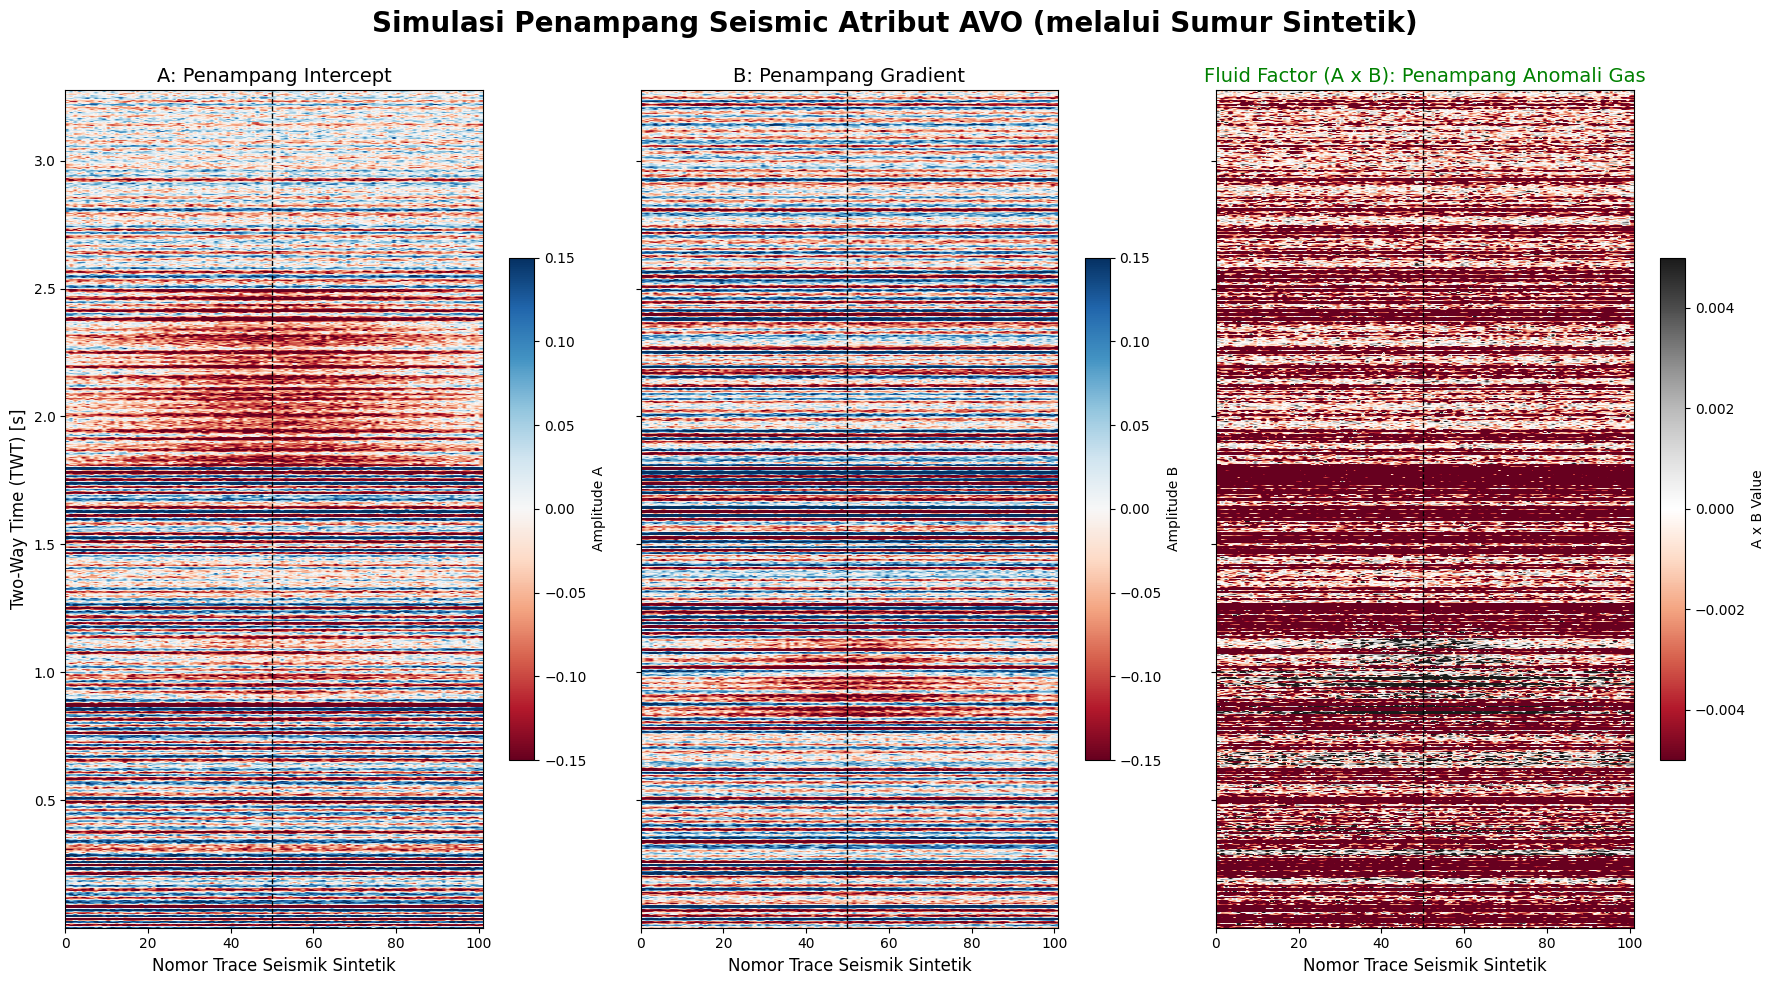

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ========================================================
# 1. SETUP DATA DASAR (Dari langkah sebelumnya)
# ========================================================
# Membaca data log sumur sintetik
df = pd.read_csv('synthetic_well_log_dataset.csv')

# Kita butuh sumur dalam domain TWT (Two-Way Time)
# Mengulangi konversi TWT dari langkah sebelumnya (jika tidak ada dalam CSV)
#dz = 1 meter dari resolusi log awal
df['dt_s'] = 1.0 / df['Vp'] # Waktu tempuh satu arah per meter
df['TWT_s'] = 2 * df['dt_s'].cumsum() # Waktu tempuh dua arah kumulatif

# Perhitungan ulang kontras antar lapisan (reflectivity) untuk Intercept A
vp1, vp2 = df['Vp'].shift(1), df['Vp']
rho1, rho2 = df['RHOB'].shift(1), df['RHOB']
A_log = 0.5 * (((vp2 - vp1) / ((vp2 + vp1)/2)) + ((rho2 - rho1) / ((rho2 + rho1)/2)))

# Perhitungan ulang Gradient B
vs1, vs2 = df['Vs'].shift(1), df['Vs']
vs_avg = (vs1 + vs2) / 2
vp_avg = (vp1 + vp2) / 2
rho_avg = (rho1 + rho2) / 2
B_log = 0.5 * ((vp2 - vp1) / vp_avg) - 2 * (vs_avg / vp_avg)**2 * (2 * ((vs2 - vs1) / vs_avg) + ((rho2 - rho1) / rho_avg))

df['Intercept_A_Log'] = A_log
df['Gradient_B_Log'] = B_log
df_avo_log = df.dropna().copy()

# ========================================================
# 2. KONVOLUSI 1D (Membuat Trace Seismik Nol)
# ========================================================
def ricker_wavelet(f_dom, dt=0.002, length=0.128):
    t = np.arange(-length/2, (length)/2, dt)
    y = (1.0 - 2.0*(np.pi**2)*(f_dom**2)*(t**2)) * np.exp(-(np.pi**2)*(f_dom**2)*(t**2))
    return t, y

dt_resample = 0.002 # 2 ms seismik
f_dom = 30 # 30 Hz wavelet
t_wavelet, wavelet = ricker_wavelet(f_dom, dt=dt_resample)

# Resample A_log dan B_log ke domain TWT yang seragam (2ms)
twt_min = np.ceil(df_avo_log['TWT_s'].min() / dt_resample) * dt_resample
twt_max = np.floor(df_avo_log['TWT_s'].max() / dt_resample) * dt_resample
t_seismic = np.arange(twt_min, twt_max, dt_resample)

A_t = np.interp(t_seismic, df_avo_log['TWT_s'], df_avo_log['Intercept_A_Log'])
B_t = np.interp(t_seismic, df_avo_log['TWT_s'], df_avo_log['Gradient_B_Log'])

# Membuat trace seismik Nol (nol-offset) di lokasi sumur (1D convolved)
seismic_A_well = np.convolve(A_t, wavelet, mode='same')
seismic_B_well = np.convolve(B_t, wavelet, mode='same')

# ========================================================
# 3. PEMODELAN PENAMPANG SEISMIK 2D SINTETIK (Pseudo-2D)
# ========================================================
num_traces = 101 # Membuat penampang lebar (lebar spasial)
well_trace_idx = 50 # Menempatkan sumur di tengah

# A. Membuat penampang lapisan datar dasar
# Menghasilkan array (waktu, trace) dari pengulangan trace sumur
section_A = np.tile(seismic_A_well[:, np.newaxis], num_traces)
section_B = np.tile(seismic_B_well[:, np.newaxis], num_traces)

# B. Menambahkan variasi lateral artifisial (Noise Seismik)
# Menambahkan Gaussian noise lateral untuk membuat seismik terlihat realistis
noise_A = np.random.normal(0, np.max(seismic_A_well)*0.15, section_A.shape)
section_A += noise_A
noise_B = np.random.normal(0, np.max(seismic_B_well)*0.15, section_B.shape)
section_B += noise_B

# C. Memodelkan Anomali Gas di Zona Dangkal (Pliosen)
# Dari tabel: Zona Dangkal (TSZ) berada di 600-1800m. 
# Kita asumsi ini berkorespondensi dengan TWT di sekitar 0.8s - 1.2s.
# Kita buat anomali yang pudar secara lateral dari sumur (anomali Kelas III khas)
time_TSZ_start_idx = np.abs(t_seismic - 0.8).argmin()
time_TSZ_end_idx = np.abs(t_seismic - 1.2).argmin()

# Membuat variasi lateral Gaussian artifisial (fading lateral)
t_coords = np.arange(num_traces)
lateral_variation_gas = np.exp(-((t_coords - well_trace_idx)**2) / (2 * (20**2))) # Anomali selebar 20 trace

# Tambahkan respon negative AVO (Class III) ekstra di zona TSZ yang pudar lateral
# Memberikan nilai negative ekstra pada A dan B
section_A[time_TSZ_start_idx:time_TSZ_end_idx, :] += -0.05 * lateral_variation_gas
section_B[time_TSZ_start_idx:time_TSZ_end_idx, :] += -0.08 * lateral_variation_gas

# D. Menghitung Penampang Seismik Fluid Factor (A x B)
# FF = Penampang A * Penampang B
section_FF = section_A * section_B

# E. Menambahkan fitur geologi Overpressure (Main Zone - Miosen)
# Dari tabel: Zona Utama (TMZ) 2800-5000+m. Kita asumsi TWT > 1.8s.
# Penurunan Vp tajam (A negatif tajam) tetapi mungkin tidak terlalu kuat pada Fluid Factor.
time_TMZ_idx = np.abs(t_seismic - 1.8).argmin()
time_TMZ_end_idx = np.abs(t_seismic - 2.5).argmin()

lateral_variation_op = np.exp(-((t_coords - well_trace_idx)**2) / (2 * (30**2))) # Overpressure lebih lebar

# Perubahan Intercept tajam
section_A[time_TMZ_idx:time_TMZ_end_idx, :] += -0.10 * lateral_variation_op

# ========================================================
# 4. VISUALISASI PENAMPANG SEISMIK 2D (GRID OF PLOTS)
# ========================================================
# Mengatur skala amplitudo agar seragam dan menyoroti detail
A_clim = [-0.15, 0.15]
B_clim = [-0.15, 0.15]
FF_clim = [-0.005, 0.005] # Fluid factor jauh lebih kecil karena perkalian

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 10), sharey=True)
fig.suptitle('Simulasi Penampang Seismic Atribut AVO (melalui Sumur Sintetik)', fontsize=20, fontweight='bold')

# Setup Colormap: Red-White-Blue adalah standar seismik
# Red: Amplitudo Positif, Blue: Amplitudo Negatif
# FF membutuhkan penekanan warna berbeda jika menyoroti anomali (A*B positif)
cmap_seismic = 'RdBu' 

# Subplot 1: Penampang Intercept (A)
im1 = axes[0].imshow(section_A, aspect='auto', cmap=cmap_seismic, 
                    extent=[0, num_traces, t_seismic.max(), t_seismic.min()], 
                    vmin=A_clim[0], vmax=A_clim[1])
axes[0].set_title('A: Penampang Intercept', fontsize=14)
axes[0].set_ylabel('Two-Way Time (TWT) [s]', fontsize=12)
axes[0].set_xlabel('Nomor Trace Seismik Sintetik', fontsize=12)
axes[0].grid(False)
# Menampilkan sumur sintetik kita di tengah
axes[0].axvline(well_trace_idx, color='black', linestyle='--', linewidth=1, label='Lokasi Sumur')

# Subplot 2: Penampang Gradient (B)
im2 = axes[1].imshow(section_B, aspect='auto', cmap=cmap_seismic, 
                    extent=[0, num_traces, t_seismic.max(), t_seismic.min()], 
                    vmin=B_clim[0], vmax=B_clim[1])
axes[1].set_title('B: Penampang Gradient', fontsize=14)
axes[1].set_xlabel('Nomor Trace Seismik Sintetik', fontsize=12)
axes[1].grid(False)
axes[1].axvline(well_trace_idx, color='black', linestyle='--', linewidth=1)

# Subplot 3: Penampang Fluid Factor (A x B)
# Kita bisa menonjolkan nilai positif (lime/hijau) untuk anomali Kelas III
im3 = axes[2].imshow(section_FF, aspect='auto', cmap='RdGy', 
                    extent=[0, num_traces, t_seismic.max(), t_seismic.min()], 
                    vmin=FF_clim[0], vmax=FF_clim[1])
axes[2].set_title('Fluid Factor (A x B): Penampang Anomali Gas', fontsize=14, color='green')
axes[2].set_xlabel('Nomor Trace Seismik Sintetik', fontsize=12)
axes[2].grid(False)
axes[2].axvline(well_trace_idx, color='black', linestyle='--', linewidth=1)

# Menambahkan Colorbar (Legenda Amplitudo)
fig.colorbar(im1, ax=axes[0], shrink=0.6, label='Amplitude A')
fig.colorbar(im2, ax=axes[1], shrink=0.6, label='Amplitude B')
fig.colorbar(im3, ax=axes[2], shrink=0.6, label='A x B Value')

# Invert Y Axis untuk seismik (Waktu berjalan ke bawah)
for ax in axes:
    ax.invert_yaxis()

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# New Project

## Data Set V.2

In [1]:
"""
SINTETIK WELL LOG DATASET - VERSI UPGRADE (REALISTIS)
=======================================================
Perbaikan utama dari skrip dasar:
  1. Vsh/GR/Phi dibangun dari sekuens litofasies (bed sand-shale acak dengan
     ketebalan eksponensial) + smoothing, BUKAN random independen per 1 m
     -> hasilnya punya "karakter log" & kontinuitas vertikal yang wajar.
  2. Tren kompaksi normal (Hukum Athy): porositas turun eksponensial
     terhadap kedalaman, berbeda untuk end-member sand vs shale.
  3. Matriks efektif (rho_ma, Vp_ma, Vs) dicampur berdasarkan Vsh, sehingga
     shale ikut memengaruhi elastisitas batuan (tidak hanya lewat porositas).
  4. Vp matrix batupasir dikoreksi ke ~5480 m/s (setara DTma 55.5 us/ft),
     nilai 3950 m/s pada skrip awal terlalu lambat untuk matriks kuarsa.
  5. Saturasi fluida TIDAK LAGI lepas dari litologi: dideteksi tubuh
     reservoir (sand body) otomatis, tiap tubuh diberi tipe fluida & kontak
     (GWC/OWC) sendiri, dengan model saturasi-tinggi (transition zone) yang
     bergantung pada porositas & Vsh -> non-reservoir otomatis Sw=1.
  6. Overpressure dimodel lewat SATU parameter rasio tekanan pori yang
     mengontrol anomali porositas (undercompaction) DAN penurunan Vp/RHOB
     secara konsisten (bukan dua faktor acak yang lepas satu sama lain).
  7. Vs pakai mudrock line berbeda utk sand vs shale (Castagna), dicampur
     berdasarkan Vsh.
  8. Ditambah log yang tadinya tidak ada: NPHI (dengan efek gas ->
     crossover neutron-densitas), RT/resistivity (persamaan Simandoux +
     Rw yang menurun terhadap kedalaman via gradien geotermal & formula
     Arps), Caliper (dengan washout di zona lunak/overpressure -> merusak
     kualitas RHOB/NPHI di sana, sesuai artefak logging riil), VpVs ratio,
     Poisson's ratio, PHIE, dan flag Pay/Bad-hole.

CATATAN: Ini tetap model sintetik yang disederhanakan untuk keperluan
latihan/riset, bukan simulasi tool-physics penuh. Semua konstanta
petrofisika (Rw, Rsh, gradien geotermal, dsb.) adalah asumsi umum khas
cekungan tersier, bukan hasil kalibrasi lapangan.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d, label

SEED = 42
np.random.seed(SEED)

# ==========================================================
# 1. SETUP KEDALAMAN & PARAMETER FISIKA DASAR
# ==========================================================
depth = np.arange(600, 5001, 1).astype(float)
n = len(depth)

# --- Matriks (end-member sand murni & shale murni) ---
rho_ma_sand, vp_ma_sand = 2.65, 5480.0   # kuarsa/batupasir bersih (DTma ~55.5 us/ft)
rho_ma_shale, vp_ma_shale = 2.70, 3600.0  # matriks shale (clay platelet, lebih lunak)

# --- Fluida ---
rho_w, vp_w = 1.05, 1650.0   # brine
rho_o, vp_o = 0.80, 1300.0   # light oil
rho_g, vp_g = 0.20, 480.0    # biogenic gas dangkal (tekanan rendah)

# --- Parameter Archie / Simandoux untuk resistivitas ---
a_arch, m_arch, n_arch = 1.0, 2.0, 2.0
Rsh = 3.0          # ohm.m, resistivitas shale (konduktif krn clay)
Rw_ref, T_ref_C = 0.35, 25.0   # ohm.m pada suhu referensi 25 C
T_surface_C = 26.0
geothermal_grad = 0.028        # deg C / m (~28 C/km, khas cekungan tersier)

# ==========================================================
# 2. FUNGSI BANTUAN
# ==========================================================
def smooth_noise(size, sigma, scale):
    """Noise putih yang di-smooth (mimikri resolusi vertikal tool & kontinuitas batuan)."""
    raw = np.random.normal(0, 1, size)
    sm = gaussian_filter1d(raw, sigma=sigma)
    sm = sm / (sm.std() + 1e-9) * scale
    return sm


def generate_vsh_sequence(size, mean_sand_m, mean_shale_m, vsh_sand_range,
                           vsh_shale_range, transition_sigma=1.3, noise_scale=0.03):
    """Bangun kurva Vsh dari sekuens lapisan sand/shale acak (tebal ~eksponensial),
    lalu dihaluskan (batas lapisan tidak pernah benar-benar kotak sempurna di log
    riil) dan ditambah heterogenitas kecil berkorelasi."""
    vsh_target = np.zeros(size)
    pos = 0
    is_sand = np.random.rand() < 0.5
    while pos < size:
        mean_th = mean_sand_m if is_sand else mean_shale_m
        thickness = max(1, int(round(np.random.exponential(mean_th))))
        val = np.random.uniform(*(vsh_sand_range if is_sand else vsh_shale_range))
        end = min(pos + thickness, size)
        vsh_target[pos:end] = val
        pos = end
        is_sand = not is_sand
    vsh_smooth = gaussian_filter1d(vsh_target, sigma=transition_sigma)
    vsh_smooth = vsh_smooth + smooth_noise(size, sigma=1.2, scale=noise_scale)
    return np.clip(vsh_smooth, 0.02, 0.98)


def assign_fluids_to_sand_bodies(depth_zone, vsh_zone, phi_zone, vsh_cutoff,
                                  phi_cutoff, fluid_probs, min_body_thick=2):
    """Deteksi tubuh reservoir (sand body) yang menerus, lalu berikan tiap tubuh
    tipe fluida & kontak (GWC/OWC) sendiri dengan model saturasi-tinggi (transition
    zone) yang tergantung kualitas batuan. Interval non-reservoir tetap Sw=1."""
    size = len(depth_zone)
    sw = np.ones(size)
    so = np.zeros(size)
    sg = np.zeros(size)
    pay_flag = np.zeros(size, dtype=int)

    is_reservoir = (vsh_zone < vsh_cutoff) & (phi_zone > phi_cutoff)
    labeled, num_bodies = label(is_reservoir)

    fluid_types = list(fluid_probs.keys())
    fluid_p = list(fluid_probs.values())

    for body_id in range(1, num_bodies + 1):
        body_idx = np.where(labeled == body_id)[0]
        if len(body_idx) < min_body_thick:
            continue  # tubuh terlalu tipis, dianggap non-reservoir efektif

        top_d, base_d = depth_zone[body_idx[0]], depth_zone[body_idx[-1]]
        fluid_type = np.random.choice(fluid_types, p=fluid_p)
        if fluid_type == 'wet':
            continue  # tetap Sw = 1

        # posisi kontak fluida relatif terhadap tubuh reservoir;
        # frac > 1 berarti kontak di bawah dasar tubuh -> full hydrocarbon column
        contact_frac = np.random.uniform(0.25, 1.15)
        contact_depth = top_d + contact_frac * (base_d - top_d)

        for idx in body_idx:
            z = depth_zone[idx]
            phi_l, vsh_l = phi_zone[idx], vsh_zone[idx]
            swirr = np.clip(0.12 + 0.35 * vsh_l, 0.10, 0.65)
            lam = np.clip(80.0 - 220.0 * phi_l, 8.0, 120.0)  # batuan bagus -> transisi lbh tajam
            if z < contact_depth:
                h = contact_depth - z
                sw_val = swirr + (1 - swirr) * np.exp(-h / lam)
                if sw_val < 0.60:   # cutoff Sw standar utk net pay (bukan sekadar "di atas kontak")
                    pay_flag[idx] = 1
            else:
                sw_val = 1.0
            sw[idx] = sw_val
            if fluid_type == 'gas':
                sg[idx] = 1 - sw_val
            elif fluid_type == 'oil':
                so[idx] = 1 - sw_val
    return sw, so, sg, pay_flag


# ==========================================================
# 3. DEFINISI ZONA GEOLOGI (indeks)
# ==========================================================
idx_shallow = (depth >= 600) & (depth < 1800)   # Zona Dangkal (TSZ) - Pliosen
idx_trans = (depth >= 1800) & (depth < 2800)    # Zona Transisi - Intrabeta & SU1
idx_main = (depth >= 2800) & (depth <= 5000)    # Zona Utama (TMZ) - Miosen
idx_op = (depth >= 3800) & (depth <= 4500)      # Anomali overpressure

# ==========================================================
# 4. BANGUN VSH PER ZONA (sekuens litofasies)
# ==========================================================
vsh = np.zeros(n)
vsh[idx_shallow] = generate_vsh_sequence(
    idx_shallow.sum(), mean_sand_m=3.0, mean_shale_m=2.5,
    vsh_sand_range=(0.05, 0.30), vsh_shale_range=(0.55, 0.90))
vsh[idx_trans] = generate_vsh_sequence(
    idx_trans.sum(), mean_sand_m=4.5, mean_shale_m=4.0,
    vsh_sand_range=(0.08, 0.35), vsh_shale_range=(0.55, 0.92))
vsh[idx_main] = generate_vsh_sequence(
    idx_main.sum(), mean_sand_m=6.0, mean_shale_m=7.0,
    vsh_sand_range=(0.05, 0.30), vsh_shale_range=(0.55, 0.95))

# ==========================================================
# 5. POROSITAS: TREN KOMPAKSI NORMAL (Hukum Athy) + heterogenitas
# ==========================================================
phi0_sand, c_sand = 0.39, 0.000271    # sand bersih: ~33% @600m -> ~10% @5000m
phi0_shale, c_shale = 0.65, 0.000514  # shale: ~48% @600m -> ~5% @5000m (lebih cepat kompaksi)

phi_trend_sand = phi0_sand * np.exp(-c_sand * depth)
phi_trend_shale = phi0_shale * np.exp(-c_shale * depth)
phi_trend = (1 - vsh) * phi_trend_sand + vsh * phi_trend_shale
phi = phi_trend + smooth_noise(n, sigma=2.0, scale=0.02)
phi = np.clip(phi, 0.02, 0.40)

# --- Overpressure: undercompaction -> porositas TERTAHAN tinggi (retained porosity) ---
# Satu parameter rasio tekanan pori mengendalikan anomali porositas & Vp/RHOB sekaligus
n_op = idx_op.sum()
op_ratio = np.zeros(n)
op_ratio[idx_op] = np.random.uniform(1.10, 1.35, n_op)  # rasio thd tekanan pori normal
phi[idx_op] += 0.09 * (op_ratio[idx_op] - 1.0) / 0.35
phi = np.clip(phi, 0.02, 0.42)

# ==========================================================
# 6. SATURASI FLUIDA (dikaitkan dengan tubuh reservoir, bukan acak lepas)
# ==========================================================
sw, so, sg = np.zeros(n), np.zeros(n), np.zeros(n)
pay_flag = np.zeros(n, dtype=int)

# Zona dangkal: sistem gas biogenik dangkal murni (gas/wet saja, tidak ada minyak)
sw_s, so_s, sg_s, pf_s = assign_fluids_to_sand_bodies(
    depth[idx_shallow], vsh[idx_shallow], phi[idx_shallow],
    vsh_cutoff=0.40, phi_cutoff=0.15,
    fluid_probs={'gas': 0.55, 'wet': 0.45})
sw[idx_shallow], so[idx_shallow], sg[idx_shallow], pay_flag[idx_shallow] = sw_s, so_s, sg_s, pf_s

# Zona transisi: campuran gas/minyak/wet (multi-fluid, sesuai catatan asli)
sw_t, so_t, sg_t, pf_t = assign_fluids_to_sand_bodies(
    depth[idx_trans], vsh[idx_trans], phi[idx_trans],
    vsh_cutoff=0.45, phi_cutoff=0.12,
    fluid_probs={'gas': 0.20, 'oil': 0.40, 'wet': 0.40})
sw[idx_trans], so[idx_trans], sg[idx_trans], pay_flag[idx_trans] = sw_t, so_t, sg_t, pf_t

# Zona utama: dominan reservoir minyak Miosen + interval wet
sw_m, so_m, sg_m, pf_m = assign_fluids_to_sand_bodies(
    depth[idx_main], vsh[idx_main], phi[idx_main],
    vsh_cutoff=0.45, phi_cutoff=0.08,
    fluid_probs={'oil': 0.45, 'wet': 0.55})
sw[idx_main], so[idx_main], sg[idx_main], pay_flag[idx_main] = sw_m, so_m, sg_m, pf_m

# ==========================================================
# 7. GAMMA RAY
# ==========================================================
gr = 20 + vsh * (120 - 20) + smooth_noise(n, sigma=1.0, scale=3.5)
gr = np.clip(gr, 10, 160)

# ==========================================================
# 8. DENSITAS & KECEPATAN (matriks efektif tergantung Vsh)
# ==========================================================
rho_ma_eff = (1 - vsh) * rho_ma_sand + vsh * rho_ma_shale
dt_ma_eff = (1 - vsh) / vp_ma_sand + vsh / vp_ma_shale  # mixing di domain slowness

rho_fl = sw * rho_w + sg * rho_g + so * rho_o
rhob = phi * rho_fl + (1 - phi) * rho_ma_eff
rhob += smooth_noise(n, sigma=1.0, scale=0.01)

dt_fl = sw / vp_w + sg / vp_g + so / vp_o
dt_fl = np.where((sw + sg + so) <= 0, 1 / vp_w, dt_fl)
dt_log = phi * dt_fl + (1 - phi) * dt_ma_eff
vp = 1 / dt_log
vp *= (1 + smooth_noise(n, sigma=1.0, scale=0.01))  # noise relatif kecil ~1%

# --- Koreksi overpressure (velocity reversal khas undercompaction) ---
vp[idx_op] *= (1 - 0.22 * (op_ratio[idx_op] - 1.0) / 0.35)
rhob[idx_op] *= (1 - 0.06 * (op_ratio[idx_op] - 1.0) / 0.35)

# ==========================================================
# 9. Vs (mudrock line berbeda utk sand vs shale - Castagna)
# ==========================================================
vs_sand = 0.804 * vp - 856.0
vs_shale = 0.862 * vp - 1172.0
vs = (1 - vsh) * vs_sand + vsh * vs_shale
vs = np.clip(vs, 500, None)

vp_vs_ratio = vp / vs
poisson_ratio = (vp_vs_ratio**2 - 2) / (2 * (vp_vs_ratio**2 - 1))

# Impedansi Akustik
ai = vp * rhob

# ==========================================================
# 10. NEUTRON POROSITY (NPHI) - dengan efek gas (crossover)
# ==========================================================
hi_water, hi_oil, hi_gas = 1.00, 0.90, 0.25   # hydrogen index relatif per fluida
nphi_fluid_resp = sw * hi_water + so * hi_oil + sg * hi_gas
nphi_true = phi * nphi_fluid_resp
shale_bound_water = vsh * 0.35 * (1 - phi)     # sinyal apparent dari clay-bound water
nphi = nphi_true + shale_bound_water + smooth_noise(n, sigma=1.0, scale=0.012)
nphi = np.clip(nphi, 0.0, 0.60)

# Porositas efektif (perkiraan sederhana, mengurangi kontribusi bound water shale)
phie = np.clip(phi * (1 - 0.3 * vsh), 0.0, 0.40)

# ==========================================================
# 11. RESISTIVITY (Simandoux) + Rw terhadap suhu (gradien geotermal, Arps)
# ==========================================================
T_C = T_surface_C + geothermal_grad * depth
T_F, T_ref_F = T_C * 9 / 5 + 32, T_ref_C * 9 / 5 + 32
Rw = Rw_ref * (T_ref_F + 6.77) / (T_F + 6.77)   # formula Arps: Rw turun seiring suhu naik

sw_safe = np.clip(sw, 0.05, 1.0)
term_clean = (phi**m_arch) * (sw_safe**n_arch) / (a_arch * Rw)
term_shale = (vsh * sw_safe) / Rsh
rt = 1.0 / (term_clean + term_shale)
rt *= np.exp(smooth_noise(n, sigma=1.0, scale=0.10))  # noise log-normal ~10%
rt = np.clip(rt, 0.2, 500)

# ==========================================================
# 12. CALIPER & EFEK WASHOUT (borehole rugosity)
#     -> merusak kualitas RHOB/NPHI secara lokal, artefak logging yang umum
#        terjadi di sedimen dangkal tak terkonsolidasi & shale overpressure
# ==========================================================
bit_size = 8.5  # inch
washout_prone = idx_shallow | idx_op
washout_prob = np.where(washout_prone, 0.012, 0.002)  # peluang washout per sampel
washout_mask = np.random.rand(n) < washout_prob
washout_mask = gaussian_filter1d(washout_mask.astype(float), sigma=1.5) > 0.15

caliper = bit_size + smooth_noise(n, sigma=1.5, scale=0.15)
caliper[washout_mask] += np.random.uniform(1.5, 4.5, washout_mask.sum())
caliper = np.clip(caliper, bit_size - 0.3, bit_size + 8)
bad_hole_flag = washout_mask.astype(int)

# Di zona washout, pad tool tidak menempel sempurna -> RHOB bias rendah & noise naik,
# NPHI bias tinggi (efek mud/fluid tambahan terbaca sbg hidrogen)
rhob[washout_mask] -= np.random.uniform(0.03, 0.12, washout_mask.sum())
rhob[washout_mask] += smooth_noise(washout_mask.sum(), sigma=1.0, scale=0.02)
nphi[washout_mask] += np.random.uniform(0.02, 0.08, washout_mask.sum())
nphi = np.clip(nphi, 0.0, 0.60)
ai = vp * rhob  # AI dihitung ulang setelah efek washout pd RHOB

# ==========================================================
# 13. SUSUN DATAFRAME
# ==========================================================
df_well = pd.DataFrame({
    'Depth_m': depth,
    'GR': gr,
    'CALI': caliper,
    'Vsh': vsh,
    'PHIT': phi,
    'PHIE': phie,
    'NPHI': nphi,
    'RHOB': rhob,
    'RT': rt,
    'Vp': vp,
    'Vs': vs,
    'VpVs': vp_vs_ratio,
    'PoissonRatio': poisson_ratio,
    'AI': ai,
    'Sw': sw,
    'So': so,
    'Sg': sg,
    'Zone': '',
    'Overpressure_Flag': 0,
    'Bad_Hole_Flag': bad_hole_flag,
    'Pay_Flag': pay_flag,
})

df_well.loc[idx_shallow, 'Zone'] = 'Zona Dangkal (TSZ)'
df_well.loc[idx_trans, 'Zone'] = 'Zona Transisi'
df_well.loc[idx_main, 'Zone'] = 'Zona Utama (TMZ)'
df_well.loc[idx_op, 'Overpressure_Flag'] = 1

# ==========================================================
# 14. VISUALISASI (LOG PLOT) - triple-combo style + resistivity + crossover
# ==========================================================
fig, ax = plt.subplots(nrows=1, ncols=6, figsize=(19, 11), sharey=True)
fig.suptitle('Sintetik Well Log v2 - Litofasies, Kompaksi, Kontak Fluida & Efek Lubang Bor',
             fontsize=14)

# Track 1: GR + Caliper
ax[0].plot(df_well['GR'], df_well['Depth_m'], color='green', linewidth=0.7)
ax[0].set_xlabel('Gamma Ray (API)', color='green')
ax[0].set_xlim(0, 150)
ax[0].grid(True, linestyle=':', alpha=0.5)
ax0_t = ax[0].twiny()
ax0_t.plot(df_well['CALI'], df_well['Depth_m'], color='saddlebrown', linewidth=0.6, alpha=0.8)
ax0_t.set_xlim(6, 16)
ax0_t.set_xlabel('Caliper (in)', color='saddlebrown')

# Track 2: Resistivity (log scale)
ax[1].semilogx(df_well['RT'], df_well['Depth_m'], color='red', linewidth=0.7)
ax[1].set_xlim(0.2, 500)
ax[1].set_xlabel('RT (ohm.m)', color='red')
ax[1].grid(True, which='both', linestyle=':', alpha=0.5)

# Track 3: Densitas-Neutron crossover (indikator gas)
ax[2].plot(df_well['RHOB'], df_well['Depth_m'], color='black', linewidth=0.7)
ax[2].set_xlim(1.90, 2.95)
ax[2].set_xlabel('RHOB (g/cc)')
ax[2].grid(True, linestyle=':', alpha=0.5)
ax2_t = ax[2].twiny()
ax2_t.plot(df_well['NPHI'], df_well['Depth_m'], color='blue', linewidth=0.7)
ax2_t.set_xlim(0.45, -0.15)  # dibalik: standar overlay density-neutron
ax2_t.set_xlabel('NPHI (v/v)', color='blue')

# Track 4: Porositas & Saturasi
ax[3].plot(df_well['PHIT'] * 100, df_well['Depth_m'], color='blue', linewidth=0.7, label='PHIT')
ax[3].plot(df_well['PHIE'] * 100, df_well['Depth_m'], color='navy', linewidth=0.6,
           linestyle='--', label='PHIE')
ax[3].set_xlim(0, 45)
ax[3].set_xlabel('Porosity (%)')
ax[3].legend(loc='upper right', fontsize=7)
ax[3].grid(True, linestyle=':', alpha=0.5)
ax3_t = ax[3].twiny()
ax3_t.fill_betweenx(df_well['Depth_m'], 0, df_well['Sg'] * 100, color='red', alpha=0.35, label='Sg')
ax3_t.fill_betweenx(df_well['Depth_m'], df_well['Sg'] * 100, (df_well['Sg'] + df_well['So']) * 100,
                     color='green', alpha=0.35, label='So')
ax3_t.set_xlim(0, 100)
ax3_t.set_xlabel('Saturation (%)')

# Track 5: Vp & Vs
ax[4].plot(df_well['Vp'], df_well['Depth_m'], color='blue', linewidth=0.7, label='Vp')
ax[4].plot(df_well['Vs'], df_well['Depth_m'], color='red', linewidth=0.7, label='Vs')
ax[4].set_xlim(400, 6000)
ax[4].set_xlabel('Velocity (m/s)')
ax[4].legend(loc='upper right', fontsize=7)
ax[4].grid(True, linestyle=':', alpha=0.5)

# Track 6: Zona geologi, overpressure, bad hole, pay
ax[5].fill_betweenx(df_well['Depth_m'], 0, 1, where=idx_shallow, color='lightcyan', label='Dangkal (Gas)')
ax[5].fill_betweenx(df_well['Depth_m'], 0, 1, where=idx_trans, color='khaki', label='Transisi (Multi)')
ax[5].fill_betweenx(df_well['Depth_m'], 0, 1, where=idx_main, color='mistyrose', label='Utama (Miosen)')
ax[5].fill_betweenx(df_well['Depth_m'], 0, 1, where=idx_op, color='red', alpha=0.25, label='Overpressure')
ax[5].fill_betweenx(df_well['Depth_m'], 0, 0.15, where=df_well['Pay_Flag'] == 1,
                     color='black', label='Pay')
ax[5].fill_betweenx(df_well['Depth_m'], 0.85, 1, where=df_well['Bad_Hole_Flag'] == 1,
                     color='saddlebrown', label='Bad hole')
ax[5].set_xlim(0, 1)
ax[5].set_xticks([])
ax[5].set_xlabel('Zona & Flag')
ax[5].legend(loc='upper right', fontsize=6.5)

ax[0].invert_yaxis()
ax[0].set_ylabel('Depth (mTVDss)')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig('synthetic_well_log_v2_plot.png', dpi=150, bbox_inches='tight')
plt.close()

# ==========================================================
# 15. EXPORT KE CSV
# ==========================================================
csv_filename = 'synthetic_well_log_dataset_v2.csv'
df_well.to_csv(csv_filename, index=False)
print(f"Data set berhasil disimpan ke: {csv_filename}")
print(f"Plot log disimpan ke: synthetic_well_log_v2_plot.png")
print(df_well.describe().T[['min', 'mean', 'max']])

Data set berhasil disimpan ke: synthetic_well_log_dataset_v2.csv
Plot log disimpan ke: synthetic_well_log_v2_plot.png
                           min         mean           max
Depth_m             600.000000  2800.000000   5000.000000
GR                   15.012294    66.622335    120.235732
CALI                  8.200000     8.551250     13.070704
Vsh                   0.020000     0.465657      0.980000
PHIT                  0.023711     0.198441      0.400000
PHIE                  0.017715     0.171553      0.366557
NPHI                  0.083061     0.328072      0.580820
RHOB                  1.846500     2.332468      2.665082
RT                    0.900641     2.802203     14.776323
Vp                 1422.915253  3232.548279   4624.715747
Vs                  500.000000  1682.323742   2858.781705
VpVs                  1.617723     1.966111      3.537948
PoissonRatio          0.190790     0.315482      0.456586
AI                 2665.864131  7591.422031  11848.775796
Sw          

In [4]:
"""
AVO (Amplitude Versus Offset) ANALYSIS - VERSI UPGRADE
=========================================================
Perbaikan dari skrip dasar:
  1. Pakai dataset well log v2 (RT, NPHI, Pay_Flag, kontak fluida per sand
     body, dll - lihat synthetic_well_log_v2.py).
  2. Vp/Vs/RHOB di-BLOCK (rata-rata di grid waktu seismik) SEBELUM
     reflektivitas dihitung, bukan dihitung di resolusi log 1 m lalu
     di-interpolasi ke grid waktu. Interpolasi naif berisiko under-sample
     reflektor tipis (aliasing); block-averaging di domain waktu adalah
     alur standar sebelum membuat sintetik seismogram / well tie.
  3. Ada koreksi checkshot/overburden (0 - 600 m, di atas log) supaya TWT
     tidak diam-diam menganggap kedalaman itu tidak makan waktu.
  4. Shuey 3-TERM (A, B, C), bukan 2-term saja - pada sudut 40 derajat
     dengan kontras sekuat pasir gas dangkal, term kelengkungan (C) mulai
     berkontribusi dan 2-term mulai menyimpang.
  5. Ditambah noise band-limited pada gather (S/N terbatas, bukan gather
     "bersih sempurna") dan efek NMO-stretch sederhana (trace sudut jauh
     jadi berfrekuensi lebih rendah), dua artefak yang selalu muncul pada
     gather riil.
  6. Zoom gather TIDAK di-hardcode; skrip mendeteksi otomatis interval
     gas-sand terbesar (Sg tertinggi & menerus) lalu zoom ke situ +
     padding, dan melaporkan kedalaman aslinya di konsol.
  7. Crossplot A-B diwarnai berdasarkan Pay_Flag + Sg/So (bukan cutoff
     Sg>0.5 yang di v2 nyaris tak pernah tercapai karena sistem saturasi
     sudah gradual/realistis), dan diberi anotasi Kuadran III (area khas
     anomali Class 3 - soft gas sand, relevan utk skenario gas biogenik
     dangkal di dataset ini).

CATATAN KETERBATASAN:
  - Shuey (2 atau 3 term) tetap aproksimasi linier dari Zoeppritz penuh,
    dan tidak menangani sudut kritis (total internal reflection) yang
    berpotensi muncul pada kontras Vp seekstrem pasir gas dangkal di
    dataset ini. Untuk analisis kuantitatif serius pada kontras seperti
    ini, bandingkan dengan Zoeppritz penuh.
  - Efek NMO-stretch di sini adalah pendekatan kualitatif (frekuensi
    wavelet diturunkan terhadap sudut), bukan turunan dari persamaan
    moveout yang sebenarnya.
  - Semua konstanta (kecepatan overburden, level noise, dsb.) adalah
    asumsi umum, bukan kalibrasi lapangan.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import label

SEED = 7
np.random.seed(SEED)

# ==========================================================
# 1. BACA DATASET & TIME-DEPTH CONVERSION (dgn koreksi overburden)
# ==========================================================
df = pd.read_csv('synthetic_well_log_dataset_v2.csv')
dz = 1.0  # resolusi log (m)

v_overburden_avg = 1700.0  # m/s, asumsi kecepatan rata2 sedimen sangat dangkal (0-600 m)
top_depth = df['Depth_m'].iloc[0]
t_top_log = top_depth / v_overburden_avg  # one-way time perkiraan ke puncak log

df['dt_s'] = dz / df['Vp']                       # one-way time per meter di dalam log
df['TWT'] = 2 * (t_top_log + df['dt_s'].cumsum())  # TWT total dari permukaan

# ==========================================================
# 2. BLOCKING LOG KE GRID WAKTU SEISMIK (2 ms) - hindari aliasing
#    Vp di-block via harmonic mean (rata2 slowness, konsisten dgn cara
#    TWT dihitung); Vs & RHOB via arithmetic mean (praktik umum).
# ==========================================================
dt_resample = 0.002  # resolusi seismik standar (2 ms)

t0_grid = np.floor(df['TWT'].min() / dt_resample) * dt_resample
df['TimeBin'] = np.floor((df['TWT'] - t0_grid) / dt_resample).astype(int)

agg = df.groupby('TimeBin').agg(
    Depth_m=('Depth_m', 'mean'),
    Slowness=('Vp', lambda x: np.mean(1.0 / x)),
    Vs=('Vs', 'mean'),
    RHOB=('RHOB', 'mean'),
    Sw=('Sw', 'mean'), So=('So', 'mean'), Sg=('Sg', 'mean'),
    Vsh=('Vsh', 'mean'),
    Pay_Flag=('Pay_Flag', 'max'),
    Overpressure_Flag=('Overpressure_Flag', 'max'),
).reset_index()
agg['Vp'] = 1.0 / agg['Slowness']

# Isi ulang ke grid bin yang benar2 kontinu (jaga2 kalau ada bin kosong krn
# interval Vp sangat tinggi -> sedikit sampel log per 2ms), lalu interpolasi
# kecil kalau ada gap, supaya sumbu waktu konvolusi nanti benar2 seragam.
full_bins = np.arange(agg['TimeBin'].min(), agg['TimeBin'].max() + 1)
agg = agg.set_index('TimeBin').reindex(full_bins).interpolate(limit_direction='both')
agg['TWT'] = t0_grid + full_bins * dt_resample
agg = agg.reset_index(drop=True)

# ==========================================================
# 3. KONTRAS ANTAR LAPISAN (dari log yang sudah di-block ke skala seismik)
# ==========================================================
vp1, vp2 = agg['Vp'].shift(1), agg['Vp']
d_vp, avg_vp = vp2 - vp1, (vp1 + vp2) / 2

vs1, vs2 = agg['Vs'].shift(1), agg['Vs']
d_vs, avg_vs = vs2 - vs1, (vs1 + vs2) / 2

rho1, rho2 = agg['RHOB'].shift(1), agg['RHOB']
d_rho, avg_rho = rho2 - rho1, (rho1 + rho2) / 2

# ==========================================================
# 4. APROKSIMASI SHUEY 3-TERM & FLUID FACTOR
# ==========================================================
A = 0.5 * ((d_vp / avg_vp) + (d_rho / avg_rho))
B = (0.5 * (d_vp / avg_vp)
     - 2 * (avg_vs / avg_vp) ** 2 * (2 * (d_vs / avg_vs) + (d_rho / avg_rho)))
C = 0.5 * (d_vp / avg_vp)  # term kelengkungan, mulai berkontribusi di sudut besar

agg['Intercept_A'] = A
agg['Gradient_B'] = B
agg['Curvature_C'] = C
agg_avo = agg.dropna().reset_index(drop=True)
agg_avo['A_times_B'] = agg_avo['Intercept_A'] * agg_avo['Gradient_B']

# ==========================================================
# 5. RICKER WAVELET (+ versi "stretch" per sudut utk efek NMO-stretch)
# ==========================================================
def ricker_wavelet(f_dom, dt=0.002, length=0.128):
    t = np.arange(-length / 2, length / 2, dt)
    y = (1.0 - 2.0 * (np.pi ** 2) * (f_dom ** 2) * (t ** 2)) * np.exp(-(np.pi ** 2) * (f_dom ** 2) * (t ** 2))
    return t, y

f_dom = 30  # Hz
t_wavelet, wavelet = ricker_wavelet(f_dom, dt=dt_resample)

# ==========================================================
# 6. SYNTHETIC ANGLE GATHER (Shuey 3-term + NMO-stretch + noise)
# ==========================================================
angles = np.arange(0, 50, 10)  # 0, 10, 20, 30, 40 derajat
t_resampled = agg_avo['TWT'].values
A_t, B_t, C_t = agg_avo['Intercept_A'].values, agg_avo['Gradient_B'].values, agg_avo['Curvature_C'].values

k_stretch = 0.35   # kekuatan efek NMO-stretch (kualitatif)
noise_frac = 0.20  # noise band-limited relatif thd RMS sinyal per-trace

gather = np.zeros((len(t_resampled), len(angles)))
for i, theta in enumerate(angles):
    theta_rad = np.radians(theta)
    R_theta = A_t + B_t * np.sin(theta_rad) ** 2 + C_t * (np.tan(theta_rad) ** 2 - np.sin(theta_rad) ** 2)

    # Wavelet sudut jauh "melebar" (frekuensi turun) - mimikri NMO-stretch
    stretch = 1 + k_stretch * np.sin(theta_rad) ** 2
    _, wavelet_theta = ricker_wavelet(f_dom / stretch, dt=dt_resample, length=0.128 * stretch)

    trace = np.convolve(R_theta, wavelet_theta, mode='same')

    # Noise band-limited (white noise dikonvolusi wavelet yg sama -> punya
    # kandungan frekuensi mirip sinyal, bukan spike acak yg tak fisis)
    raw_noise = np.random.normal(0, 1, len(R_theta))
    band_noise = np.convolve(raw_noise, wavelet_theta, mode='same')
    band_noise *= noise_frac * (np.std(trace) / (np.std(band_noise) + 1e-12))

    gather[:, i] = trace + band_noise

# ==========================================================
# 7. AUTO-DETEKSI ZONA FOKUS (interval gas-sand terbesar & menerus)
# ==========================================================
gas_mask = (agg_avo['Sg'] > 0.3).values
labeled, num_bodies = label(gas_mask)
if num_bodies > 0:
    sizes = [(labeled == i).sum() for i in range(1, num_bodies + 1)]
    best_body = np.argmax(sizes) + 1
    idxs = np.where(labeled == best_body)[0]
    zoom_t_min = max(t_resampled.min(), agg_avo['TWT'].iloc[idxs[0]] - 0.05)
    zoom_t_max = min(t_resampled.max(), agg_avo['TWT'].iloc[idxs[-1]] + 0.05)
    zoom_depth = (agg_avo['Depth_m'].iloc[idxs[0]], agg_avo['Depth_m'].iloc[idxs[-1]])
    print(f"Fokus gather otomatis: interval gas-sand terbesar di kedalaman "
          f"{zoom_depth[0]:.0f}-{zoom_depth[1]:.0f} m (TWT {zoom_t_min:.3f}-{zoom_t_max:.3f} s)")
else:
    zoom_t_min, zoom_t_max = t_resampled.min(), t_resampled.max()
    print("Tidak ditemukan interval gas-sand signifikan, gather ditampilkan penuh.")

# ==========================================================
# 8. VISUALISASI (GridSpec)
# ==========================================================
fig = plt.figure(figsize=(18, 9))
gs = gridspec.GridSpec(3, 6, wspace=0.5, hspace=0.8)

# --- Subplot 1: Crossplot A vs B, klasifikasi via Pay_Flag + Sg/So ---
ax1 = fig.add_subplot(gs[:, 0:2])
gas_sands = agg_avo[(agg_avo['Pay_Flag'] == 1) & (agg_avo['Sg'] > 0)]
oil_sands = agg_avo[(agg_avo['Pay_Flag'] == 1) & (agg_avo['So'] > 0)]
background = agg_avo[agg_avo['Pay_Flag'] == 0]

ax1.scatter(background['Intercept_A'], background['Gradient_B'], c='lightgrey',
            alpha=0.4, s=8, label='Background (non-pay)')
if len(oil_sands):
    ax1.scatter(oil_sands['Intercept_A'], oil_sands['Gradient_B'], c=oil_sands['So'],
                cmap='Greens', edgecolors='k', linewidth=0.4, s=28, label='Oil sand (pay)')
if len(gas_sands):
    sc = ax1.scatter(gas_sands['Intercept_A'], gas_sands['Gradient_B'], c=gas_sands['Sg'],
                      cmap='Reds', edgecolors='k', linewidth=0.4, s=28, label='Gas sand (pay)')
    plt.colorbar(sc, ax=ax1, label='Sg / So (pay only)', orientation='horizontal', pad=0.12)
ax1.axhline(0, color='black', lw=1, linestyle='--')
ax1.axvline(0, color='black', lw=1, linestyle='--')
ax1.text(-0.20, -0.20, 'Kuadran III\n(khas Class 3\nsoft gas sand)', fontsize=7,
         color='darkred', ha='left', va='bottom', style='italic')
ax1.set_xlabel('Intercept (A)')
ax1.set_ylabel('Gradient (B)')
ax1.set_title('AVO Crossplot')
ax1.set_xlim(-0.25, 0.25)
ax1.set_ylim(-0.25, 0.25)
ax1.legend(loc='upper left', fontsize=7)
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Subplot 2: Log atribut AVO ---
ax2 = fig.add_subplot(gs[:, 2])
ax2.plot(agg_avo['Intercept_A'], agg_avo['Depth_m'], color='blue', linewidth=0.8, label='A')
ax2.plot(agg_avo['Gradient_B'], agg_avo['Depth_m'], color='red', linewidth=0.8, alpha=0.7, label='B')
ax2.invert_yaxis()
ax2.set_xlabel('Amplitude')
ax2.set_title('AVO Attributes')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, linestyle=':', alpha=0.6)

# --- Subplot 3: Fluid Factor ---
ax3 = fig.add_subplot(gs[:, 3], sharey=ax2)
ax3.plot(agg_avo['A_times_B'], agg_avo['Depth_m'], color='green', linewidth=1)
thresh = agg_avo['A_times_B'].quantile(0.97)  # ambang berbasis persentil, bukan angka tetap
ax3.fill_betweenx(agg_avo['Depth_m'], 0, agg_avo['A_times_B'],
                   where=(agg_avo['A_times_B'] > thresh), color='lime', alpha=0.6)
ax3.set_xlabel('A * B')
ax3.set_title('Fluid Factor (A x B)')
ax3.grid(True, linestyle=':', alpha=0.6)

# --- Subplot 4: Ricker wavelet (referensi, sudut 0 derajat) ---
ax4 = fig.add_subplot(gs[0, 4:6])
ax4.plot(t_wavelet * 1000, wavelet, color='black')
ax4.fill_between(t_wavelet * 1000, wavelet, 0, where=(wavelet > 0), color='black')
ax4.set_title(f'Ricker Wavelet ({f_dom} Hz, referensi @0°)')
ax4.set_xlabel('Time (ms)')
ax4.set_ylabel('Amplitude')
ax4.grid(True, linestyle=':', alpha=0.6)

# --- Subplot 5: Synthetic Angle Gather (+ noise + NMO-stretch) ---
ax5 = fig.add_subplot(gs[1:3, 4:6])
scaling_factor = 1.5 / np.max(np.abs(gather))
for i, theta in enumerate(angles):
    scaled_trace = gather[:, i] * scaling_factor
    offset = i
    ax5.plot(offset + scaled_trace, t_resampled, color='black', linewidth=0.5)
    ax5.fill_betweenx(t_resampled, offset, offset + scaled_trace,
                       where=(scaled_trace > 0), color='black')
ax5.set_xticks(range(len(angles)))
ax5.set_xticklabels([f'{a}°' for a in angles])
ax5.set_xlabel('Angle (degree)')
ax5.set_ylabel('Two-Way Time (s)')
ax5.set_title('Synthetic Angle Gather (+ noise & NMO-stretch)')
ax5.invert_yaxis()
ax5.grid(True, linestyle=':', alpha=0.6)
ax5.set_ylim(zoom_t_max, zoom_t_min)  # auto-zoom ke interval gas-sand terdeteksi

plt.savefig('avo_analysis_v2_plot.png', dpi=150, bbox_inches='tight')
plt.close()
plt.show()
print("Plot AVO disimpan ke: avo_analysis_v2_plot.png")

Fokus gather otomatis: interval gas-sand terbesar di kedalaman 955-966 m (TWT 0.932-1.046 s)
Plot AVO disimpan ke: avo_analysis_v2_plot.png


In [5]:
"""
PENAMPANG SEISMIK PSEUDO-2D (INTERCEPT, GRADIENT, FLUID FACTOR)
=================================================================
Perbaikan dari skrip dasar:
  1. Pakai dataset v2 + block-averaging ke skala seismik + koreksi
     checkshot/overburden, konsisten dengan alur di avo_analysis_v2.py
     (menghindari aliasing reflektor & TWT yang salah anchor).
  2. Jendela TWT zona TSZ (gas dangkal) & overpressure DIHITUNG dari TWT
     sumur yang sebenarnya, bukan ditebak. Hasilnya: TSZ ~0.71-1.57 s,
     overpressure ~2.75-3.23 s -- BUKAN 0.8-1.2 s / 1.8-2.5 s seperti
     tebakan di skrip asli (overpressure aslinya meleset cukup jauh).
  3. Anomali gas dangkal dimodel sebagai geobodi kanal/lobe yang
     "meander" (lebar & posisi berubah tak beraturan secara lateral,
     lewat random walk yang di-smooth), BUKAN Gaussian simetris sempurna
     yang persis terpusat di sumur -- bentuk itu terlalu rapi utk geobodi
     riil dan agak sirkular (seolah "membuktikan" anomali di sekitar
     sumur padahal memang digambar begitu). Geobodi tetap dijamin
     melewati sumur (karena sumur memang menembusnya), tapi bentuk di
     tempat lain dibiarkan tak beraturan seperti hasil interpretasi
     nyata dengan ketidakpastian.
  4. Anomali overpressure diubah jadi medan lateral yang menerus secara
     regional (magnitudonya bervariasi, tapi TIDAK fade ke nol menjauhi
     sumur) -- overpressure adalah fenomena pembebanan/penguburan yang
     regional, bukan pinch-out stratigrafi lokal seperti kanal pasir.
     Menyamakan bentuknya dengan anomali gas sand (skrip asli) keliru
     secara konsep.
  5. Noise lateral dibuat berkorelasi (smoothing 2D), bukan Gaussian
     independen per piksel -- noise seismik riil punya kontinuitas
     spasial/temporal.
  6. Ditambah relief struktur halus (closure rendah) yang menggeser
     seluruh kolom waktu per trace -- merepresentasikan bahwa sumur
     eksplorasi biasanya memang diposisikan di puncak struktur.
  7. Bug kecil diperbaiki: skrip asli bilang "menonjolkan nilai positif
     dengan warna hijau/lime" pada Fluid Factor tapi memakai cmap RdGy
     yang tidak punya hijau sama sekali. Diganti ke PRGn (positif=hijau)
     supaya sesuai klaimnya.

CATATAN KETERBATASAN: Ini tetap model pseudo-2D yang disederhanakan
(properti sumur digeser & dimodifikasi secara lateral, bukan hasil
forward-modeling elastik penuh pada model geologi 3D). Bentuk geobodi
& parameter noise adalah ilustrasi ketidakpastian interpretasi, bukan
prediksi kuantitatif bentuk sebenarnya.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, gaussian_filter1d

SEED = 17
rng = np.random.default_rng(SEED)

# ==========================================================
# 1. DATA SUMUR: TWT (dgn koreksi checkshot) + BLOCKING KE SKALA SEISMIK
#    (identik dengan alur avo_analysis_v2.py, supaya konsisten)
# ==========================================================
df = pd.read_csv('synthetic_well_log_dataset_v2.csv')

v_overburden_avg = 1700.0
top_depth = df['Depth_m'].iloc[0]
t_top_log = top_depth / v_overburden_avg

df['dt_s'] = 1.0 / df['Vp']
df['TWT_s'] = 2 * (t_top_log + df['dt_s'].cumsum())

dt_resample = 0.002
t0_grid = np.floor(df['TWT_s'].min() / dt_resample) * dt_resample
df['TimeBin'] = np.floor((df['TWT_s'] - t0_grid) / dt_resample).astype(int)

agg = df.groupby('TimeBin').agg(
    Depth_m=('Depth_m', 'mean'),
    Slowness=('Vp', lambda x: np.mean(1.0 / x)),
    Vs=('Vs', 'mean'),
    RHOB=('RHOB', 'mean'),
    Overpressure_Flag=('Overpressure_Flag', 'max'),
).reset_index()
agg['Vp'] = 1.0 / agg['Slowness']

full_bins = np.arange(agg['TimeBin'].min(), agg['TimeBin'].max() + 1)
agg = agg.set_index('TimeBin').reindex(full_bins).interpolate(limit_direction='both')
agg['TWT_s'] = t0_grid + full_bins * dt_resample
agg = agg.reset_index(drop=True)

# ==========================================================
# 2. REFLEKTIVITAS (Shuey 2-term - cukup krn di sini A & B dipakai
#    langsung sbg penampang, bukan disintesis per sudut)
# ==========================================================
vp1, vp2 = agg['Vp'].shift(1), agg['Vp']
rho1, rho2 = agg['RHOB'].shift(1), agg['RHOB']
vs1, vs2 = agg['Vs'].shift(1), agg['Vs']
vp_avg, rho_avg, vs_avg = (vp1 + vp2) / 2, (rho1 + rho2) / 2, (vs1 + vs2) / 2

A_log = 0.5 * (((vp2 - vp1) / vp_avg) + ((rho2 - rho1) / rho_avg))
B_log = (0.5 * ((vp2 - vp1) / vp_avg)
         - 2 * (vs_avg / vp_avg) ** 2 * (2 * ((vs2 - vs1) / vs_avg) + ((rho2 - rho1) / rho_avg)))

agg['Intercept_A_Log'] = A_log
agg['Gradient_B_Log'] = B_log
df_avo_log = agg.dropna().reset_index(drop=True)

# --- Jendela TWT zona geologi, DIHITUNG dari data (bukan ditebak) ---
idx_shallow_well = (df['Depth_m'] >= 600) & (df['Depth_m'] < 1800)
idx_op_well = df['Overpressure_Flag'] == 1
twt_tsz = (df.loc[idx_shallow_well, 'TWT_s'].min(), df.loc[idx_shallow_well, 'TWT_s'].max())
twt_op = (df.loc[idx_op_well, 'TWT_s'].min(), df.loc[idx_op_well, 'TWT_s'].max())
print(f"TWT zona gas dangkal (TSZ) dari data sumur : {twt_tsz[0]:.3f} - {twt_tsz[1]:.3f} s")
print(f"TWT zona overpressure dari data sumur       : {twt_op[0]:.3f} - {twt_op[1]:.3f} s")

# ==========================================================
# 3. KONVOLUSI 1D DI LOKASI SUMUR
# ==========================================================
def ricker_wavelet(f_dom, dt=0.002, length=0.128):
    t = np.arange(-length / 2, length / 2, dt)
    y = (1.0 - 2.0 * (np.pi ** 2) * (f_dom ** 2) * (t ** 2)) * np.exp(-(np.pi ** 2) * (f_dom ** 2) * (t ** 2))
    return t, y

f_dom = 30
t_seismic = df_avo_log['TWT_s'].values
_, wavelet = ricker_wavelet(f_dom, dt=dt_resample)

seismic_A_well = np.convolve(df_avo_log['Intercept_A_Log'].values, wavelet, mode='same')
seismic_B_well = np.convolve(df_avo_log['Gradient_B_Log'].values, wavelet, mode='same')

# ==========================================================
# 4. PENAMPANG PSEUDO-2D (domain "flat"/didatumkan dulu)
# ==========================================================
num_traces = 101
well_trace_idx = 50

section_A = np.tile(seismic_A_well[:, np.newaxis], num_traces)
section_B = np.tile(seismic_B_well[:, np.newaxis], num_traces)

# --- A. Noise lateral BERKORELASI (bukan independen per piksel) ---
noise_A_raw = rng.normal(0, 1, section_A.shape)
noise_A = gaussian_filter(noise_A_raw, sigma=(3, 2.5))
noise_A *= (np.max(np.abs(seismic_A_well)) * 0.15) / (noise_A.std() + 1e-12)

noise_B_raw = rng.normal(0, 1, section_B.shape)
noise_B = gaussian_filter(noise_B_raw, sigma=(3, 2.5))
noise_B *= (np.max(np.abs(seismic_B_well)) * 0.15) / (noise_B.std() + 1e-12)

section_A += noise_A
section_B += noise_B

# --- B. Geobodi kanal/lobe utk anomali gas dangkal (meander, bukan Gaussian simetris) ---
x = np.arange(num_traces)
walk = np.cumsum(rng.normal(0, 1.3, num_traces))
walk_smooth = gaussian_filter1d(walk, sigma=8)
centerline = well_trace_idx + (walk_smooth - walk_smooth[well_trace_idx])  # dijamin lewat sumur

base_half_width = 16
width_noise = gaussian_filter1d(rng.normal(0, 1, num_traces), sigma=10)
half_width = np.clip(base_half_width + 7 * width_noise, 5, None)

dist_norm = (x - centerline) / half_width
lateral_presence_gas = np.exp(-dist_norm ** 2)  # penampang lensa/kanal khas, meander sepanjang lintasan

# taper vertikal (anomali terikat ke satu reflektor, bukan blok kotak penuh)
tsz_mid = 0.5 * (twt_tsz[0] + twt_tsz[1])
tsz_half_span = 0.5 * (twt_tsz[1] - twt_tsz[0])
vert_taper_gas = np.exp(-((t_seismic - tsz_mid) ** 2) / (2 * (tsz_half_span * 0.6) ** 2))

anomaly_gas_A = -0.05 * np.outer(vert_taper_gas, lateral_presence_gas)
anomaly_gas_B = -0.08 * np.outer(vert_taper_gas, lateral_presence_gas)
section_A += anomaly_gas_A
section_B += anomaly_gas_B

# --- C. Medan overpressure REGIONAL (menerus lateral, bukan bullseye di sumur) ---
lateral_field_op = gaussian_filter1d(rng.normal(0, 1, num_traces), sigma=15)
lateral_field_op = (lateral_field_op - lateral_field_op.min()) / (np.ptp(lateral_field_op) + 1e-12)
lateral_variation_op = 0.55 + 0.45 * lateral_field_op  # tetap ada di seluruh lebar (0.55-1.0), bukan fade ke 0

# taper vertikal lunak (logistic) di tepi zona, bukan potongan kotak keras
def soft_edge_taper(t, t0, t1, softness=0.03):
    up = 1 / (1 + np.exp(-(t - t0) / softness))
    down = 1 / (1 + np.exp((t - t1) / softness))
    return up * down

vert_taper_op = soft_edge_taper(t_seismic, twt_op[0], twt_op[1])
anomaly_op_A = -0.10 * np.outer(vert_taper_op, lateral_variation_op)
section_A += anomaly_op_A

# --- D. Fluid Factor (dihitung dari section domain-flat) ---
section_FF = section_A * section_B

# ==========================================================
# 5. RELIEF STRUKTUR (closure rendah, diterapkan sbg pergeseran waktu
#    per trace pada seluruh kolom - stratigrafi & noise sudah dimodel
#    dulu di domain "flat" datum, struktur ditumpangkan terakhir)
# ==========================================================
struct_relief_s = 0.015   # 15 ms relief total -- closure sangat halus/subtil
struct_width_tr = 30
crest_trace = well_trace_idx  # umum: sumur eksplorasi diposisikan di puncak struktur
structure_shift = -struct_relief_s * np.exp(-((x - crest_trace) ** 2) / (2 * struct_width_tr ** 2))

def apply_structure(section, t_axis, shift_per_trace):
    out = np.empty_like(section)
    for tr in range(section.shape[1]):
        src_t = t_axis - shift_per_trace[tr]
        out[:, tr] = np.interp(src_t, t_axis, section[:, tr])
    return out

section_A = apply_structure(section_A, t_seismic, structure_shift)
section_B = apply_structure(section_B, t_seismic, structure_shift)
section_FF = apply_structure(section_FF, t_seismic, structure_shift)

# Horizon referensi (top TSZ) utk digambar di penampang, ikut terangkat oleh struktur
horizon_top_tsz = twt_tsz[0] + structure_shift

# ==========================================================
# 6. VISUALISASI
# ==========================================================
A_clim, B_clim = [-0.15, 0.15], [-0.15, 0.15]
FF_clim = [-0.006, 0.006]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 10), sharey=True)
fig.suptitle('Simulasi Penampang Seismik Atribut AVO (Pseudo-2D, melalui Sumur Sintetik)',
             fontsize=18, fontweight='bold')

im1 = axes[0].imshow(section_A, aspect='auto', cmap='RdBu', interpolation='bilinear',
                      extent=[0, num_traces, t_seismic.max(), t_seismic.min()],
                      vmin=A_clim[0], vmax=A_clim[1])
axes[0].set_title('A: Penampang Intercept', fontsize=13)
axes[0].set_ylabel('Two-Way Time (TWT) [s]', fontsize=11)
axes[0].set_xlabel('Nomor Trace', fontsize=11)

im2 = axes[1].imshow(section_B, aspect='auto', cmap='RdBu', interpolation='bilinear',
                      extent=[0, num_traces, t_seismic.max(), t_seismic.min()],
                      vmin=B_clim[0], vmax=B_clim[1])
axes[1].set_title('B: Penampang Gradient', fontsize=13)
axes[1].set_xlabel('Nomor Trace', fontsize=11)

im3 = axes[2].imshow(section_FF, aspect='auto', cmap='PRGn', interpolation='bilinear',
                      extent=[0, num_traces, t_seismic.max(), t_seismic.min()],
                      vmin=FF_clim[0], vmax=FF_clim[1])
axes[2].set_title('Fluid Factor (A x B) - hijau = anomali positif', fontsize=13, color='darkgreen')
axes[2].set_xlabel('Nomor Trace', fontsize=11)

for ax in axes:
    ax.grid(False)
    ax.axvline(well_trace_idx, color='black', linestyle='--', linewidth=1)
    ax.plot(x, horizon_top_tsz, color='dimgray', linewidth=0.8, linestyle=':',
            alpha=0.8)  # horizon referensi top TSZ, ikut relief struktur
    ax.invert_yaxis()
axes[0].plot([], [], color='black', linestyle='--', linewidth=1, label='Lokasi sumur')
axes[0].plot([], [], color='dimgray', linewidth=0.8, linestyle=':', label='Horizon top TSZ (data)')
axes[0].legend(loc='lower right', fontsize=8)

fig.colorbar(im1, ax=axes[0], shrink=0.6, label='Amplitude A')
fig.colorbar(im2, ax=axes[1], shrink=0.6, label='Amplitude B')
fig.colorbar(im3, ax=axes[2], shrink=0.6, label='A x B Value')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.savefig('seismic_section_v2_plot.png', dpi=150, bbox_inches='tight')
plt.close()
print("Plot penampang seismik disimpan ke: seismic_section_v2_plot.png")

TWT zona gas dangkal (TSZ) dari data sumur : 0.707 - 1.569 s
TWT zona overpressure dari data sumur       : 2.750 - 3.226 s
Plot penampang seismik disimpan ke: seismic_section_v2_plot.png
